# Uncertainty and Risk Communication (Solution)

Visualize uncertainty with error bars, confidence bands, and scenario fans.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "owid_co2_subset.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/owid_co2_subset.csv")

root = resolve_repo_root()
df = pd.read_csv(root / "data" / "owid_co2_subset.csv")
df = df[df["iso_code"].astype(str).str.len() == 3].copy()
d_recent = df[df["year"] >= 2000].copy()
latest_year = (
    d_recent.dropna(subset=["co2_per_capita", "gdp", "population"])
    ["year"]
    .max()
)
d_latest = d_recent[d_recent["year"] == latest_year].copy()
d_latest.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,coal_co2,energy_per_capita,gas_co2,methane,nitrous_oxide,oil_co2,primary_energy_consumption,temperature_change_from_ghg,trade_co2
32,Afghanistan,2022,AFG,40578847.0,5.330347e+10,10.170,0.251,3.488,1111.573,0.143,16.076,4.419,6.528,45.106,0.001,NaN
67,Albania,2022,ALB,2827614.0,3.617101e+10,4.498,1.591,0.542,9147.205,0.088,2.431,0.864,2.946,25.865,0.000,1.188
102,Algeria,2022,DZA,45477391.0,5.958201e+11,192.779,4.239,0.758,16145.337,101.379,67.576,8.200,61.610,734.248,0.005,NaN
137,Andorra,2022,AND,79722.0,NaN,0.423,5.311,0.000,NaN,0.007,0.079,0.038,0.416,NaN,0.000,NaN
172,Angola,2022,AGO,35635028.0,1.583462e+11,21.089,0.592,NaN,2713.824,1.927,45.564,17.332,14.887,96.707,0.006,NaN


## 1) Error bar chart theo nhom

/var/folders/v6/3bggzf691gn6h26h5hxxgq400000gp/T/ipykernel_90718/1343062135.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = work.groupby('gdp_q', as_index=False)['co2_per_capita'].agg(mean='mean', std='std', count='count')


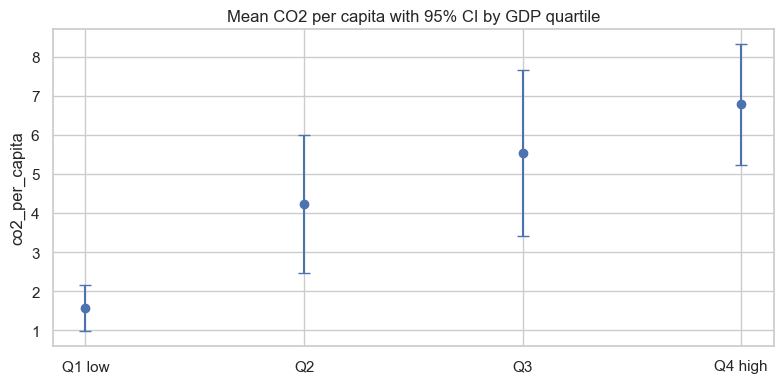

In [2]:
# Group by income-like proxy: split countries into GDP quartiles
work = d_latest.dropna(subset=['gdp', 'co2_per_capita']).copy()
work['gdp_q'] = pd.qcut(work['gdp'], q=4, labels=['Q1 low','Q2','Q3','Q4 high'])
agg = work.groupby('gdp_q', as_index=False)['co2_per_capita'].agg(mean='mean', std='std', count='count')
agg['se'] = agg['std'] / np.sqrt(agg['count'])
agg['ci95'] = 1.96 * agg['se']

plt.figure(figsize=(8,4))
plt.errorbar(agg['gdp_q'], agg['mean'], yerr=agg['ci95'], fmt='o', capsize=4)
plt.title('Mean CO2 per capita with 95% CI by GDP quartile')
plt.ylabel('co2_per_capita')
plt.tight_layout(); plt.show()

## 2) Confidence band theo thoi gian

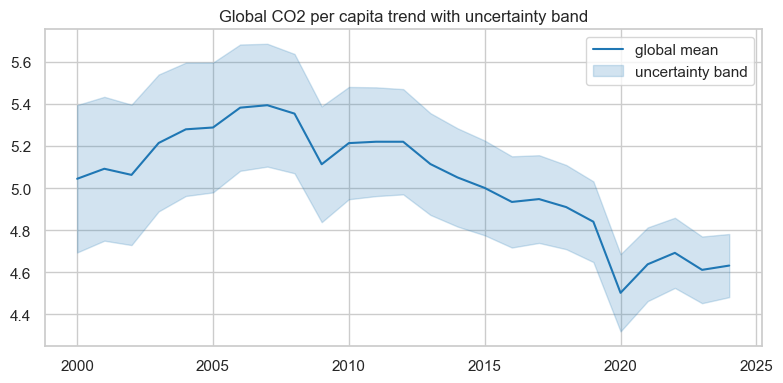

In [3]:
trend = d_recent.groupby('year', as_index=False)['co2_per_capita'].mean().dropna()
x = trend['year'].to_numpy()
y = trend['co2_per_capita'].to_numpy()
# illustrative uncertainty envelope (wider in older years)
band = np.linspace(0.35, 0.15, len(x))

plt.figure(figsize=(8,4))
plt.plot(x, y, color='#1f77b4', label='global mean')
plt.fill_between(x, y-band, y+band, alpha=0.2, color='#1f77b4', label='uncertainty band')
plt.legend(); plt.title('Global CO2 per capita trend with uncertainty band')
plt.tight_layout(); plt.show()

## 3) Scenario fan chart (toy)

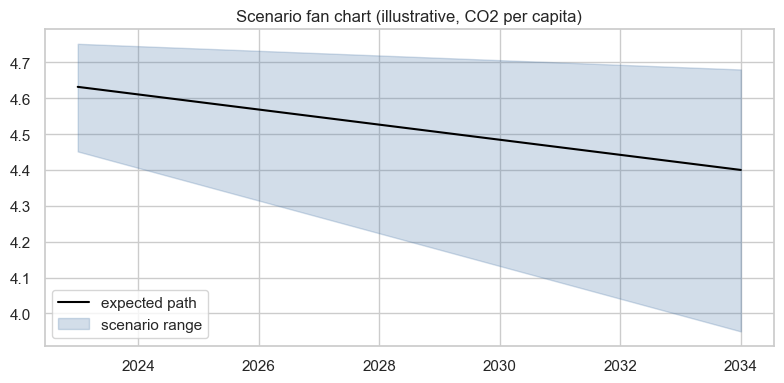

In [4]:
years = np.arange(d_latest['year'].max() + 1, d_latest['year'].max() + 13)
base0 = d_recent.groupby('year', as_index=False)['co2_per_capita'].mean().dropna().iloc[-1]['co2_per_capita']
base = np.linspace(base0, base0 * 0.95, len(years))
low = base - np.linspace(0.18, 0.45, len(years))
high = base + np.linspace(0.12, 0.28, len(years))

plt.figure(figsize=(8,4))
plt.plot(years, base, color='black', label='expected path')
plt.fill_between(years, low, high, color='#4C78A8', alpha=0.25, label='scenario range')
plt.legend(); plt.title('Scenario fan chart (illustrative, CO2 per capita)')
plt.tight_layout(); plt.show()

## Reflection
- Nêu 2 điểm học được về chart selection.
- Chỉ ra 1 rủi ro diễn giải sai với loại chart trong lab này.